# Problema de Poisson

Vamos considerar o problema elíptico escalar

$$
\begin{cases}
-\Delta u = f & \text{em } \Omega = (0, 1)^2, \\
u = 0 & \text{em } \partial \Omega.
\end{cases}
$$

Este é um dos modelos mais importantes em elementos finitos porque concentra,
em um contexto simples, vários ingredientes que reaparecem em problemas mais
gerais: operador de segunda ordem, integração por partes, condição essencial
de contorno e espaço de energia $H^1$.

## Solução manufaturada

Para verificar a implementação, escolhemos uma solução exata conhecida:

$$
u_{\mathrm{ex}}(x, y) = \sin(\pi x)\sin(\pi y).
$$

Substituindo na equação, obtemos

$$
f(x, y) = 2\pi^2 \sin(\pi x)\sin(\pi y).
$$

Essa estratégia é didaticamente útil porque separa duas perguntas:

1. a formulação variacional está correta?
2. a implementação numérica reproduz a solução esperada com erro pequeno?

## Da forma forte para a forma fraca

Tomamos uma função-teste $v \in H_0^1(\Omega)$ e multiplicamos a equação por
$v$:

$$
\int_\Omega (-\Delta u)\, v \, dx = \int_\Omega f v \, dx.
$$

Aplicando integração por partes,

$$
\int_\Omega \nabla u \cdot \nabla v \, dx
- \int_{\partial \Omega} (\nabla u \cdot n) v \, ds
= \int_\Omega f v \, dx.
$$

Como $v=0$ na fronteira, o termo de contorno desaparece. Portanto, a forma
fraca é:

$$
\text{encontrar } u \in H_0^1(\Omega) \text{ tal que }
\int_\Omega \nabla u \cdot \nabla v \, dx
=
\int_\Omega f v \, dx
\quad \forall v \in H_0^1(\Omega).
$$

## Problema discreto

Escolhemos um espaço de elementos finitos contínuos lineares:

$$
V_h \subset H_0^1(\Omega).
$$

O problema discreto fica:

$$
\text{encontrar } u_h \in V_h \text{ tal que }
a(u_h, v_h) = L(v_h)
\quad \forall v_h \in V_h,
$$

com

$$
a(u_h, v_h) = \int_\Omega \nabla u_h \cdot \nabla v_h \, dx,
\qquad
L(v_h) = \int_\Omega f v_h \, dx.
$$

In [1]:
import os

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")

from mpi4py import rc

rc.finalize = False

from mpi4py import MPI

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import ufl
from dolfinx import fem, mesh, plot
from dolfinx.fem import petsc

## Malha, espaço e funções variacionais

Usaremos uma malha triangular estruturada da unidade quadrada e elementos
lineares de Lagrange.

In [2]:
nx = ny = 24
domain = mesh.create_unit_square(MPI.COMM_WORLD, nx, ny)
V = fem.functionspace(domain, ("Lagrange", 1))

u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)
x = ufl.SpatialCoordinate(domain)

u_exact = ufl.sin(ufl.pi * x[0]) * ufl.sin(ufl.pi * x[1])
f = 2 * ufl.pi**2 * u_exact

## Condição de contorno de Dirichlet

Como a solução exata se anula na fronteira, a condição homogênea é
compatível com o problema manufaturado.

In [3]:
def boundary(x):
    return (
        np.isclose(x[0], 0.0)
        | np.isclose(x[0], 1.0)
        | np.isclose(x[1], 0.0)
        | np.isclose(x[1], 1.0)
    )


boundary_dofs = fem.locate_dofs_geometrical(V, boundary)
bc = fem.dirichletbc(0.0, boundary_dofs, V)

## Montagem e solução

A tradução da formulação variacional para UFL fica exatamente na forma
matemática que acabamos de deduzir.

In [4]:
a = ufl.inner(ufl.grad(u), ufl.grad(v)) * ufl.dx
L = f * v * ufl.dx

problem = petsc.LinearProblem(
    a,
    L,
    bcs=[bc],
    petsc_options_prefix="poisson_",
    petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
)
u_h = problem.solve()
u_h.name = "u_h"

## Diagnósticos numéricos

Além do erro $L^2$, calculamos o erro no semi-norma $H^1$, que é muito
natural para o problema de Poisson porque a energia do sistema depende de
gradientes.

In [5]:
l2_error = fem.assemble_scalar(fem.form((u_h - u_exact) ** 2 * ufl.dx)) ** 0.5
h1_semi_error = (
    fem.assemble_scalar(
        fem.form(ufl.inner(ufl.grad(u_h - u_exact), ufl.grad(u_h - u_exact)) * ufl.dx)
    )
    ** 0.5
)

print(f"Erro L2:        {l2_error:.6e}")
print(f"Erro H1-semi:   {h1_semi_error:.6e}")
print(f"Graus de liberdade: {V.dofmap.index_map.size_global}")

Erro L2:        2.397960e-03
Erro H1-semi:   1.452288e-01
Graus de liberdade: 625


## Preparando campos para visualização

Vamos comparar solução exata, solução de elementos finitos e erro nodal. Como
a variável comparada é a mesma nas duas primeiras figuras, usaremos a **mesma
escala de cores** em ambas.

In [6]:
u_exact_h = fem.Function(V, name="u_ex")
u_exact_h.interpolate(lambda x: np.sin(np.pi * x[0]) * np.sin(np.pi * x[1]))

error_h = fem.Function(V, name="erro")
error_h.x.array[:] = u_h.x.array - u_exact_h.x.array

topology, _, geometry = plot.vtk_mesh(V)
triangles = topology.reshape((-1, 4))[:, 1:]
triangulation = mtri.Triangulation(geometry[:, 0], geometry[:, 1], triangles)


def contour_levels(*arrays, nlevels=25):
    vmin = min(float(np.min(values)) for values in arrays)
    vmax = max(float(np.max(values)) for values in arrays)
    if np.isclose(vmin, vmax):
        vmax = vmin + 1.0
    return np.linspace(vmin, vmax, nlevels), vmin, vmax


shared_levels, _, _ = contour_levels(u_exact_h.x.array.real, u_h.x.array.real)
error_levels, _, _ = contour_levels(error_h.x.array.real)


def plot_scalar(ax, values, title, levels, cmap):
    collection = ax.tricontourf(triangulation, values, levels=levels, cmap=cmap)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    return collection

## Malha e campos escalares

O primeiro gráfico ajuda a visualizar a discretização. Em seguida, comparamos
os campos usando a mesma faixa de cores para a solução exata e numérica.

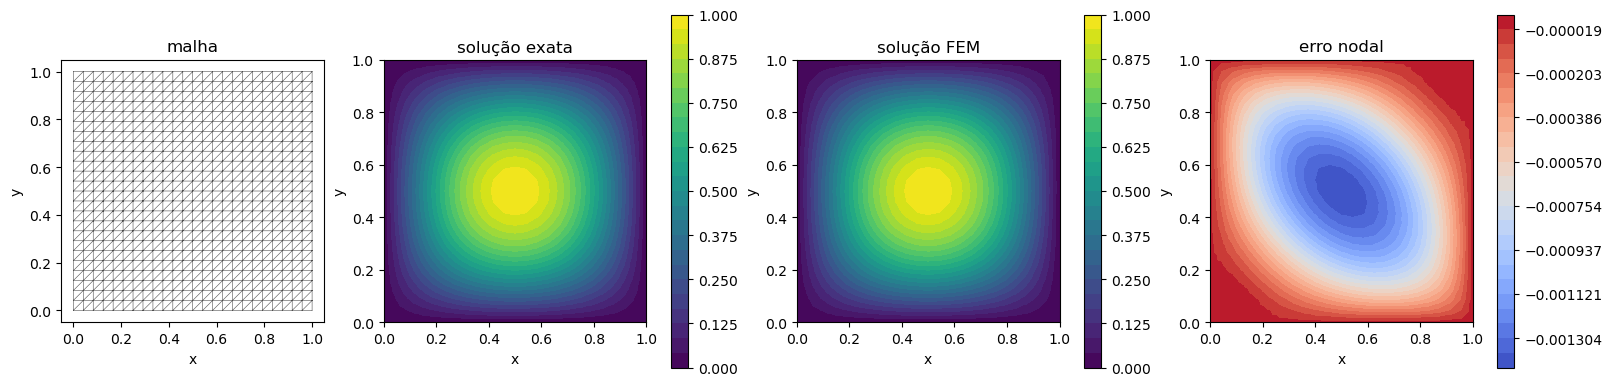

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), constrained_layout=True)

axes[0].triplot(triangulation, color="0.3", lw=0.4)
axes[0].set_aspect("equal")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("malha")

for ax, field, title, levels, cmap in [
    (axes[1], u_exact_h, "solução exata", shared_levels, "viridis"),
    (axes[2], u_h, "solução FEM", shared_levels, "viridis"),
    (axes[3], error_h, "erro nodal", error_levels, "coolwarm"),
]:
    collection = plot_scalar(ax, field.x.array.real, title, levels, cmap)
    fig.colorbar(collection, ax=ax)

plt.show()

## Corte ao longo de $y = 0.5$

Em sala, um gráfico 1D costuma ser muito útil para discutir aproximação
pontual, amplitude e simetria da solução.

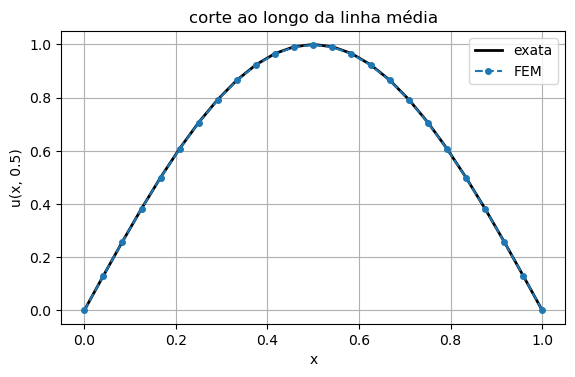

In [8]:
coords = V.tabulate_dof_coordinates()[:, :2]
mask = np.isclose(coords[:, 1], 0.5)
order = np.argsort(coords[mask, 0])
x_cut = coords[mask, 0][order]
u_exact_cut = u_exact_h.x.array.real[mask][order]
u_num_cut = u_h.x.array.real[mask][order]

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(x_cut, u_exact_cut, "-k", lw=2, label="exata")
ax.plot(x_cut, u_num_cut, "o--", ms=4, label="FEM")
ax.set_xlabel("x")
ax.set_ylabel("u(x, 0.5)")
ax.set_title("corte ao longo da linha média")
ax.grid(True)
ax.legend()
plt.show()

## Comentário final

Neste problema, a principal hipótese oculta é a regularidade da solução exata.
Como escolhemos uma solução suave, o erro observado é compatível com o uso de
elementos lineares. Em problemas com singularidades de canto ou coeficientes
descontínuos, a história pode ser bem diferente.